MIT License

Copyright (c) 2023 vccimaging

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

In [45]:
import sys
import os

from networkx import sigma
sys.path.append(os.path.abspath("../.."))
import diffinytrace as dit
from tqdm import tqdm
#%%
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import sys
import math
import diffoptics as do


In [46]:
grid_size = 256

In [47]:
device = torch.device('cuda:0')
lens = do.Lensgroup(device=device)

save_dir = './autodiff_demo/'
if not os.path.exists(save_dir):
    os.mkdir(save_dir)

R = 12.7
surfaces = [
    do.Aspheric(R, 0.0, c=0.05, device=device),
    do.Aspheric(R, 6.5, c=0., device=device)
]
materials = [
    do.Material('air'),
    do.Material('N-BK7'),
    do.Material('air')
]
lens.load(surfaces, materials)
lens.d_sensor = 25.0
lens.r_last = 12.7

# generate array of rays
wavelength = torch.Tensor([532.8]).to(device) # [nm]
cs = [0.05]#[0.045]
index = 0
c = cs[index]
num_batches = 100
final_plot_radius = None

R = 10.0 # [mm]
def render():
    ray_init = lens.sample_ray(wavelength, M=9, R=R, sampling='grid')
    ps = lens.trace_to_sensor(ray_init)
    return ps[...,:2]

def trace_all():
    ray_init = lens.sample_ray_2D(R, wavelength, M=11)
    ps, oss = lens.trace_to_sensor_r(ray_init)
    return ps[...,:2], oss

def compute_Jacobian(ps):
    Js = []
    for i in range(1):
        J = torch.zeros(torch.numel(ps))
        for j in range(torch.numel(ps)):
            mask = torch.zeros(torch.numel(ps))
            mask[j] = 1
            ps.backward(mask.reshape(ps.shape), retain_graph=True)
            J[j] = lens.surfaces[i].c.grad.item()
            lens.surfaces[i].c.grad.data.zero_()
        J = J.reshape(ps.shape)

    # get data to numpy
    Js.append(J.cpu().detach().numpy())
    return Js

lens.film_size = [grid_size, grid_size]
lens.pixel_size = (50.0e-3/2)*2
final_plot_radius = lens.film_size[0]*lens.pixel_size/2

def get_do_org_irr_and_derv():
    Iss = []
    Jss = []

    for k in [0]:
        index_string = str(index).zfill(3)
        # load optics
        lens.surfaces[0].c = torch.Tensor(np.array(c))
        lens.surfaces[0].c.requires_grad = True
        
        # show trace figure
        ps, oss = trace_all()
        ax, fig = lens.plot_raytraces(oss, color='b-', show=False)
        ax.axis('off')
        ax.set_title("")
        fig.savefig(save_dir + "layout_trace_" + index_string + ".png", bbox_inches='tight')

        # show spot diagram
        RMS = lambda ps: torch.sqrt(torch.mean(torch.sum(torch.square(ps), axis=-1)))
        ps = render()
        rms_org = RMS(ps)
        #print(f'RMS: {rms_org}')
        lens.spot_diagram(ps, xlims=[-4, 4], ylims=[-4, 4], savepath=save_dir + "spotdiagram_" + index_string + ".png", show=False)

        # compute Jacobian
        Js = compute_Jacobian(ps)[0]
        print(Js.max())
        print(Js.min())
        ps_ = ps.cpu().detach().numpy()
        fig = plt.figure()
        x, y = ps_[:,0], ps_[:,1]
        """        
        plt.plot(x, y, 'b.', zorder=0)
        plt.quiver(x, y, Js[:,0], Js[:,1], color='b', zorder=1)
        plt.xlim(-4, 4)
        plt.ylim(-4, 4)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlabel('x [mm]')
        plt.ylabel('y [mm]')
        fig.savefig(save_dir + "flow_" + index_string + ".png", bbox_inches='tight')
        """
        ray = lens.sample_ray(wavelength.item(), view=0.0, M=2049, sampling='grid')
        print(ray.o.shape)
        lens.film_size = [grid_size, grid_size]
        lens.pixel_size = (50.0e-3/2)*2
        I = lens.render(ray)
        I = I.cpu().detach().numpy()
        lm = do.LM(lens, ['surfaces[0].c'], 1e-2, option='diag')
        JI = lm.jacobian(lambda: lens.render(ray)).squeeze()
        J = JI.abs().cpu().detach().numpy()

        Iss.append(I)
        Jss.append(J)
        
    Iss = Iss[0]
    Jss = Jss[0]
    final_plot_radius = lens.film_size[0]*lens.pixel_size/2

    return Iss, Jss

def get_do_irr_and_derv(num_rays_per_batch,num_batches):
    
    if not math.sqrt(num_rays_per_batch).is_integer():
        raise RuntimeError("num_rays_per_batch should be a perfect square for this function.")
    
    M = int(math.sqrt(num_rays_per_batch))
    Iss = []
    Jss = []

    for k in range(num_batches):
        index_string = str(index).zfill(3)
        # load optics
        lens.surfaces[0].c = torch.Tensor(np.array(c))
        lens.surfaces[0].c.requires_grad = True
        
        # show trace figure
        ps, oss = trace_all()
        ax, fig = lens.plot_raytraces(oss, color='b-', show=False)
        ax.axis('off')
        ax.set_title("")
        fig.savefig(save_dir + "layout_trace_" + index_string + ".png", bbox_inches='tight')

        # show spot diagram
        RMS = lambda ps: torch.sqrt(torch.mean(torch.sum(torch.square(ps), axis=-1)))
        ps = render()
        rms_org = RMS(ps)
        #print(f'RMS: {rms_org}')
        lens.spot_diagram(ps, xlims=[-4, 4], ylims=[-4, 4], savepath=save_dir + "spotdiagram_" + index_string + ".png", show=False)

        # compute Jacobian
        Js = compute_Jacobian(ps)[0]
        print(Js.max())
        print(Js.min())
        ps_ = ps.cpu().detach().numpy()
        fig = plt.figure()
        x, y = ps_[:,0], ps_[:,1]
        """        
        plt.plot(x, y, 'b.', zorder=0)
        plt.quiver(x, y, Js[:,0], Js[:,1], color='b', zorder=1)
        plt.xlim(-4, 4)
        plt.ylim(-4, 4)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlabel('x [mm]')
        plt.ylabel('y [mm]')
        fig.savefig(save_dir + "flow_" + index_string + ".png", bbox_inches='tight')
        """
        ray = lens.sample_ray(wavelength.item(), view=0.0, M=M, sampling='random')
        print(ray.o.shape)
        lens.film_size = [grid_size, grid_size]
        lens.pixel_size = (50.0e-3/2)*2
        I = lens.render(ray)
        I = I.cpu().detach().numpy()
        lm = do.LM(lens, ['surfaces[0].c'], 1e-2, option='diag')
        JI = lm.jacobian(lambda: lens.render(ray)).squeeze()
        J = JI.abs().cpu().detach().numpy()

        Iss.append(I)
        Jss.append(J)
    
    Iss = torch.mean(torch.stack(Iss),dim=0).detach().cpu()
    Jss = torch.mean(torch.stack(Jss),dim=0).detach().cpu()
    return Iss, Jss

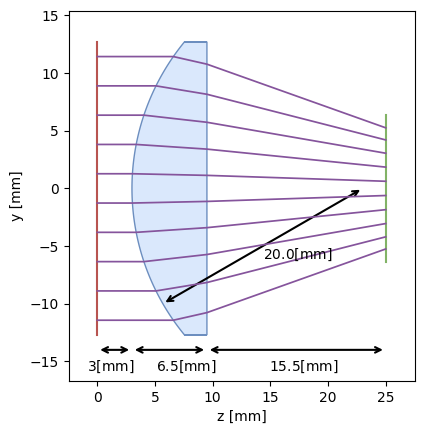

In [48]:
aperture_radius = 12.7
do_air = do.Material('air')
do_nbk7 = do.Material('N-BK7')
dit_nbk7 = dit.RefractiveIndex(lambda x:do_nbk7.A + do_nbk7.B / (x*1000)**2,[0.1,1.5])
dit_air = dit.RefractiveIndex(lambda x:do_air.A + do_air.B / (x*1000)**2,[0.1,1.5])


wave_len = 0.5328

lens_pos1D = 3.
lens_thickness = 6.5
curvature = cs[0]
detector_distance = 25.
device = "cuda:0"


light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_source = dit.source.CollimatedMonochromatic(light_transform,aperture_radius,wave_len)
light_transform.pos.requires_grad = False
#get_anchor_transform
#0.5


lens_transform = dit.transforms.Distance(lens_pos1D,parent_transform=light_transform)
lens_transform.distance.requires_grad = False
surface1 = dit.Aspheric(curvature=curvature)
surface2 = dit.Plane()
lens1 = dit.Lens(lens_transform,lens_thickness,surface1,surface2,dit_nbk7,aperture_radius)
lens1.lens_thickness.requires_grad = False

#detector_transform = dit.PositionTransform(torch.tensor([0.0,0.0,25.0+0.5]))
detector_transform = dit.transforms.Distance(detector_distance)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = dit.Plane()

detector = dit.Detector(detector_transform,plane_surface,final_plot_radius)


system = dit.SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector},n_func_enviroment = dit_air)

light_source_1D = dit.source.CollimatedMonochromatic1D(light_transform,aperture_radius,wave_len)
system_2D = dit.SequentialOpticalSystem({"source":light_source_1D,"lens":lens1,"detector":detector},n_func_enviroment = dit_air)

x,weights = light_source_1D.sample([10],"midpoint")
sequence = ["source","lens","detector"]
O,D,wave_len,_,RayPaths = system_2D(x,sequence)


dit.plotting.system2D.plot(system_2D,RayPaths,500,show = False)

offset_arrows = -14
dit.plotting.system2D.annotated_arrow([0,offset_arrows],[3,offset_arrows],(-20,-15),"$3$[mm]","<->")
dit.plotting.system2D.annotated_arrow([3,offset_arrows],[3+lens_thickness,offset_arrows],(-10,-15),f"${lens_thickness}$[mm]","<->")
dit.plotting.system2D.annotated_arrow([3+lens_thickness,offset_arrows],[detector_distance,offset_arrows],(-20,-15),f"${detector_distance-lens_thickness-3}$[mm]","<->")
import torch

def rotate_2d(v, degrees):
    # v: shape (2,) or (..., 2)
    theta = torch.deg2rad(torch.as_tensor(degrees, dtype=v.dtype, device=v.device))
    c, s = torch.cos(theta), torch.sin(theta)

    R = torch.stack([
        torch.stack([c, -s]),
        torch.stack([s,  c])
    ])  # (2, 2)

    return v @ R.T

# example
v = torch.tensor([-1/curvature, 0.0])
midpoint = torch.tensor([3+1/curvature,0])
onsurface = midpoint +rotate_2d(v,30)

dit.plotting.system2D.annotated_arrow(onsurface,midpoint,(0,-9),f"${1/curvature}$[mm]","<->")
#dit.plotting.system2D.annotated_arrow([5+2,offset_arrows],[5+2+10,offset_arrows],(0,-9),"$x$","<->")
#dit.plotting.system2D.annotate_position([0,4],(-20,20),"light source")
#dit.plotting.system2D.annotate_position([5+1,5],(-20,20),"lens")
#dit.plotting.system2D.annotate_position([5+2+10,8],(-50,10),"target")

In [92]:
#M=2049*2**2
#num_rays = (2049*2)**2
grid = dit.target_grid.GridSquare(final_plot_radius,grid_size=grid_size)
#binned_irradiance = dit.render.binned_irradiance(system,sequence,light_source,detector,grid,num_rays=num_rays,method_ray_tracing="monte_carlo")
#dit.plotting.quantity2D.plot(binned_irradiance, "Irradiance", [-final_plot_radius, final_plot_radius], [-final_plot_radius, final_plot_radius])
system.to(device)
#%%


#smoother = dit.gaussian_smoother.GaussianSmootherSquare(final_plot_radius,grid_size=grid_size,sigma=0.1,desired_irradiance_fun=lambda x: torch.zeros_like(x),smoothed_num_integration_points=8,smoothed_num_splits=1)
#dit.render.smoothed_irradiance(system,sequence,light_source,detector,smoother,num_rays=num_rays,method_ray_tracing="monte_carlo")
def _calc_rc_irr(num_rays_per_batch,num_batches):
    out_list = []
    sequence = ["source","lens","detector"]
    for k in tqdm(range(num_batches)):
        binned_irradiance = dit.render.binned_irradiance(system,sequence,light_source,detector,grid,num_rays=num_rays_per_batch,method_ray_tracing="monte_carlo",device=device)

        binned_irradiance = binned_irradiance.detach().cpu()
        out_list.append(binned_irradiance)
    out = torch.mean(torch.stack(out_list),dim=0).detach().cpu()
        
    return out

def _calc_binned_derv_v_slow(num_rays_per_batch,num_batches):
    out_list = []
    sequence = ["source","lens","detector"]
    def u_mapping(x):
        O,D,wave_len,_,RayPaths = system(x,sequence)
        O_local = detector.to_local_pos(O)
        return O_local[:,[0,1]],O
    
    for k in tqdm(range(num_batches)):
        x,weights = light_source.sample(num_rays_per_batch)
        x = x.to(device)
        weights = weights.to(device)
        
        x.requires_grad = True
        y,O = u_mapping(x)
        Qval = light_source.get_flux(x.detach()).detach()
        #Qval = Qval.to(device)  

        #constant_fac = weights.detach()
        irradiance = None
        with torch.no_grad():
            irradiance = grid.sum(y.detach(),Qval.detach()*weights.detach())/grid.get_pixel_area()
        dmdI = torch.ones_like(irradiance)
        dmdI.requires_grad = True
        dmdIk = grid.map_matrix_to_ray(detector.to_local_pos(O.detach())[:,[0,1]],dmdI).reshape(-1)
        dmdIk = dmdIk*weights.detach()/grid.get_pixel_area()
        
        dy1_dx, = dit.grad(y[:,0],inputs=[x],grad_outputs=torch.ones_like(y[:,0]))
        dy2_dx, = dit.grad(y[:,1],inputs=[x],grad_outputs=torch.ones_like(y[:,1]))
        dy_dx = torch.zeros((x.shape[0],2,2),device=device)
        dy_dx[:,0] = dy1_dx
        dy_dx[:,1] = dy2_dx
        H = torch.det(dy_dx).reshape(-1)
        #H = H+torch.sign(H)*0.001

        Q = light_source.get_flux(x)
        dQdx, = dit.grad(Q,inputs=[x],grad_outputs=torch.ones_like(Q))

        dHdx, = dit.grad(H,inputs=[x],grad_outputs=torch.ones_like(H))
        
        dy_dx_inv = torch.zeros((num_rays_per_batch,2,2),device=device)
        dy_dx_inv[:,0,0 ]= dy_dx[:,1,1]
        dy_dx_inv[:,0,1] = -dy_dx[:,0,1]
        dy_dx_inv[:,1,0] = -dy_dx[:,1,0]
        dy_dx_inv[:,1,1] = dy_dx[:,0,0]
        dy_dx_inv = dy_dx_inv/H.reshape(-1,1,1)
        
        ##print("dy_dx_inv",dy_dx_inv.device,"dHdx",dHdx.device)
        dy_dx_inv_dHdx = torch.bmm(dy_dx_inv,dHdx.reshape(-1,2,1)).reshape(-1,2)
        grad_outputs_dgdp_H = -dmdIk.reshape(-1,1)*(((1.0/H.reshape(-1,1))*dy_dx_inv_dHdx*Q.reshape(-1,1)).detach())
        grad_outputs_dHdp = -dmdIk.reshape(-1)*(((1.0/H.reshape(-1))*Q.reshape(-1)).detach())
        
        dy_dx_inv_dQdx = torch.bmm(dy_dx_inv,dQdx.reshape(-1,2,1)).reshape(-1,2)
        grad_outputs_dgdp_Q = dmdIk.reshape(-1,1)*(dy_dx_inv_dQdx.detach())
        #grad_outputs_dQdp = dmdIk.reshape(-1)

        grad_outputs_dgdp = grad_outputs_dgdp_H+grad_outputs_dgdp_Q
        
        parameter = surface1.curvature
        dHdp, = dit.grad(H,inputs=parameter,grad_outputs=grad_outputs_dHdp,materialize_grads=True)
        #dQdp, = dit.grad(Q,inputs=parameter,grad_outputs=grad_outputs_dQdp,materialize_grads=True) is Zero in this case
        dgdp_H_Q, = dit.grad(y,inputs=parameter,grad_outputs=grad_outputs_dgdp,materialize_grads=True)
        
        pgrad = dHdp+dgdp_H_Q
        tmp, = dit.grad(pgrad,inputs=[dmdI])
        tmp = tmp.detach().cpu()
        out_list.append(tmp)
    out = torch.mean(torch.stack(out_list),dim=0).detach().cpu()
        
    return out

def _calc_smooth_irr(sigma,num_rays_per_batch,num_batches):
    out_list = []
    sequence = ["source","lens","detector"]
    for k in tqdm(range(num_batches)):
        x,weights = light_source.sample(num_rays_per_batch)
        x = x.to(device)
        weights = weights.to(device)
        
        O,D,wave_len,_,RayPaths = system(x,sequence)
        Qval = light_source.get_flux(x.detach()).detach()
        tmp = dit.gaussian_smoother.gaussian_func_2D(detector.to_local_pos(O)[:,[0,1]],[-final_plot_radius,final_plot_radius],[-final_plot_radius,final_plot_radius],grid_size,grid_size,sigma,val_multi=Qval*weights,include_boundary=False)
        tmp = tmp.detach().cpu()
        out_list.append(tmp)
    out = torch.mean(torch.stack(out_list),dim=0).detach().cpu()
        
    return out

def _calc_smooth_irr_derv(sigma,num_rays_per_batch,num_batches):
    out_list = []
    sequence = ["source","lens","detector"]
    for k in tqdm(range(num_batches)):
        x,weights = light_source.sample(num_rays_per_batch)
        x = x.to(device)
        weights = weights.to(device)

        O,D,wave_len,_,RayPaths = system(x,sequence)
        Qval = light_source.get_flux(x.detach()).detach()
        
        irradiance = dit.gaussian_smoother.gaussian_func_2D(detector.to_local_pos(O)[:,[0,1]],[-final_plot_radius,final_plot_radius],[-final_plot_radius,final_plot_radius],grid_size,grid_size,sigma,val_multi=Qval*weights,include_boundary=False)
        
        tmp = torch.ones_like(irradiance)
        tmp.requires_grad = True

        dp_summed, = dit.grad(irradiance,inputs=[surface1.curvature],grad_outputs=tmp,materialize_grads=True)
            
        dIdp_classical, = dit.grad(dp_summed,inputs=[tmp])

        dIdp_classical = dIdp_classical.detach().cpu()
        out_list.append(dIdp_classical)
    out = torch.mean(torch.stack(out_list),dim=0).detach().cpu()
        
    return out

def _hat_func_2D(points, xrange, yrange, grid_size, val_multi=1.0):
    # points: (N, 2), val_multi: scalar or (N,)
    xmin, xmax = xrange
    ymin, ymax = yrange

    device = points.device
    dtype = points.dtype

    x_grid = grid.get_pixel_centers()[0,:,0]#torch.linspace(xmin, xmax, grid_size, device=device, dtype=dtype)
    y_grid = grid.get_pixel_centers()[:,0,1]#torch.linspace(ymin, ymax, grid_size, device=device, dtype=dtype)

    x_grid = x_grid.to(device=device,dtype=dtype)
    y_grid = y_grid.to(device=device,dtype=dtype)
    x_grid_delta = (xmax - xmin) / (grid_size - 1)
    y_grid_delta = (ymax - ymin) / (grid_size - 1)

    # (N, 1) - (1, G) -> (N, G)
    x_diff = torch.abs(points[:, 0:1] - x_grid[None, :])
    y_diff = torch.abs(points[:, 1:2] - y_grid[None, :])

    x_hat = torch.clamp(1.0 - x_diff / x_grid_delta, min=0.0)/ x_grid_delta
    y_hat = torch.clamp(1.0 - y_diff / y_grid_delta, min=0.0)/ y_grid_delta

    val_multi = torch.as_tensor(val_multi, device=device, dtype=dtype)
    x_hat = x_hat.T
    y_hat = y_hat.T
    #if val_multi.ndim == 0:
    #    val_multi = val_multi.expand(points.shape[0])
    #print("x_hat shape",x_hat.shape,"y_hat shape",y_hat.shape,"val_multi shape",val_multi.shape,"points shape",points.shape)
    x_hat = x_hat*val_multi.reshape(1,-1)
    #y_hat = y_hat*val_multi.reshape(1,-1)
    return x_hat@y_hat.T
    #hat_2D = (x_hat[:, :, None] * y_hat[:, None, :]) * val_multi[:, None, None]
    #return hat_2D.sum(dim=0)


def _calc_hat_fun_irr(num_rays_per_batch,num_batches):
    out_list = []
    sequence = ["source","lens","detector"]
    for k in tqdm(range(num_batches)):
        x,weights = light_source.sample(num_rays_per_batch)
        x = x.to(device)
        weights = weights.to(device)
        
        O,D,wave_len,_,RayPaths = system(x,sequence)
        Qval = light_source.get_flux(x.detach()).detach()
        tmp = _hat_func_2D(detector.to_local_pos(O)[:,[0,1]],[-final_plot_radius,final_plot_radius],[-final_plot_radius,final_plot_radius],grid_size,val_multi=Qval*weights)
        tmp = tmp.detach().cpu()
        out_list.append(tmp)
    out = torch.mean(torch.stack(out_list),dim=0).detach().cpu()
        
    return out

def _calc_hat_fun_irr_derv(num_rays_per_batch,num_batches):
    out_list = []
    sequence = ["source","lens","detector"]
    for k in tqdm(range(num_batches)):
        x,weights = light_source.sample(num_rays_per_batch)
        x = x.to(device)
        weights = weights.to(device)

        O,D,wave_len,_,RayPaths = system(x,sequence)
        Qval = light_source.get_flux(x.detach()).detach()
        
        irradiance = _hat_func_2D(detector.to_local_pos(O)[:,[0,1]],[-final_plot_radius,final_plot_radius],[-final_plot_radius,final_plot_radius],grid_size,val_multi=Qval*weights)
        
        tmp = torch.ones_like(irradiance)
        tmp.requires_grad = True

        dp_summed, = dit.grad(irradiance,inputs=[surface1.curvature],grad_outputs=tmp,materialize_grads=True)
            
        dIdp_classical, = dit.grad(dp_summed,inputs=[tmp])

        dIdp_classical = dIdp_classical.detach().cpu()
        out_list.append(dIdp_classical)
    out = torch.mean(torch.stack(out_list),dim=0).detach().cpu()
        
    return out
def calc_hat_fun_irr_and_derv(num_rays_per_batch,num_batches):
    derv = _calc_hat_fun_irr_derv(num_rays_per_batch,num_batches)
    irr = _calc_hat_fun_irr(num_rays_per_batch,num_batches)
    return irr,derv

def calc_smooth_irr_and_derv(sigma,num_rays_per_batch,num_batches):
    derv = _calc_smooth_irr_derv(sigma,num_rays_per_batch,num_batches)
    irr = _calc_smooth_irr(sigma,num_rays_per_batch,num_batches)
    return irr,derv

def calc_binned_irr_and_derv(num_rays_per_batch,num_batches):
    derv = _calc_binned_derv_v_slow(num_rays_per_batch,num_batches)
    irr = _calc_rc_irr(num_rays_per_batch,num_batches)
    return irr,derv

In [93]:
# Parameters
sigma = 0.05
num_rays_per_batch = 2**16
num_batches = 50

irr_hat, d_hat = calc_hat_fun_irr_and_derv(num_rays_per_batch, num_batches)


100%|██████████| 50/50 [00:01<00:00, 36.45it/s]


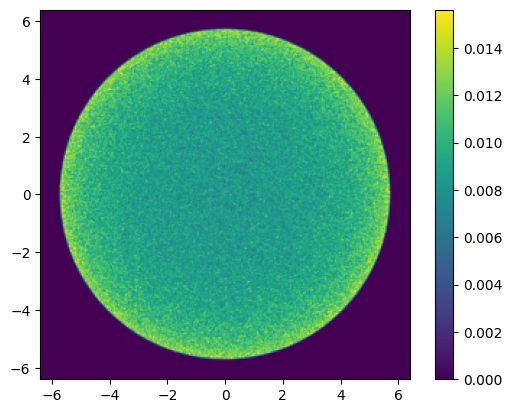

In [94]:
plt.imshow(irr_hat.cpu(), extent=[-final_plot_radius, final_plot_radius, -final_plot_radius, final_plot_radius])
plt.colorbar()

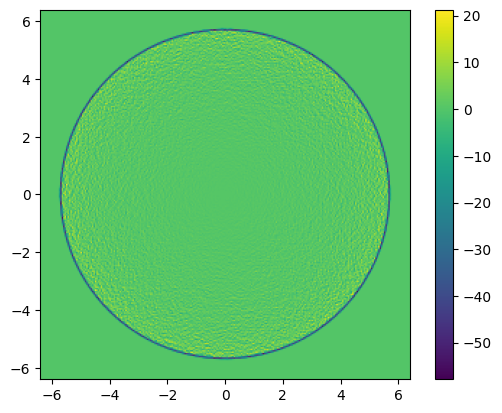

In [81]:
plt.imshow(d_hat.cpu(), extent=[-final_plot_radius, final_plot_radius, -final_plot_radius, final_plot_radius])
plt.colorbar()

100%|██████████| 100/100 [00:02<00:00, 35.15it/s]


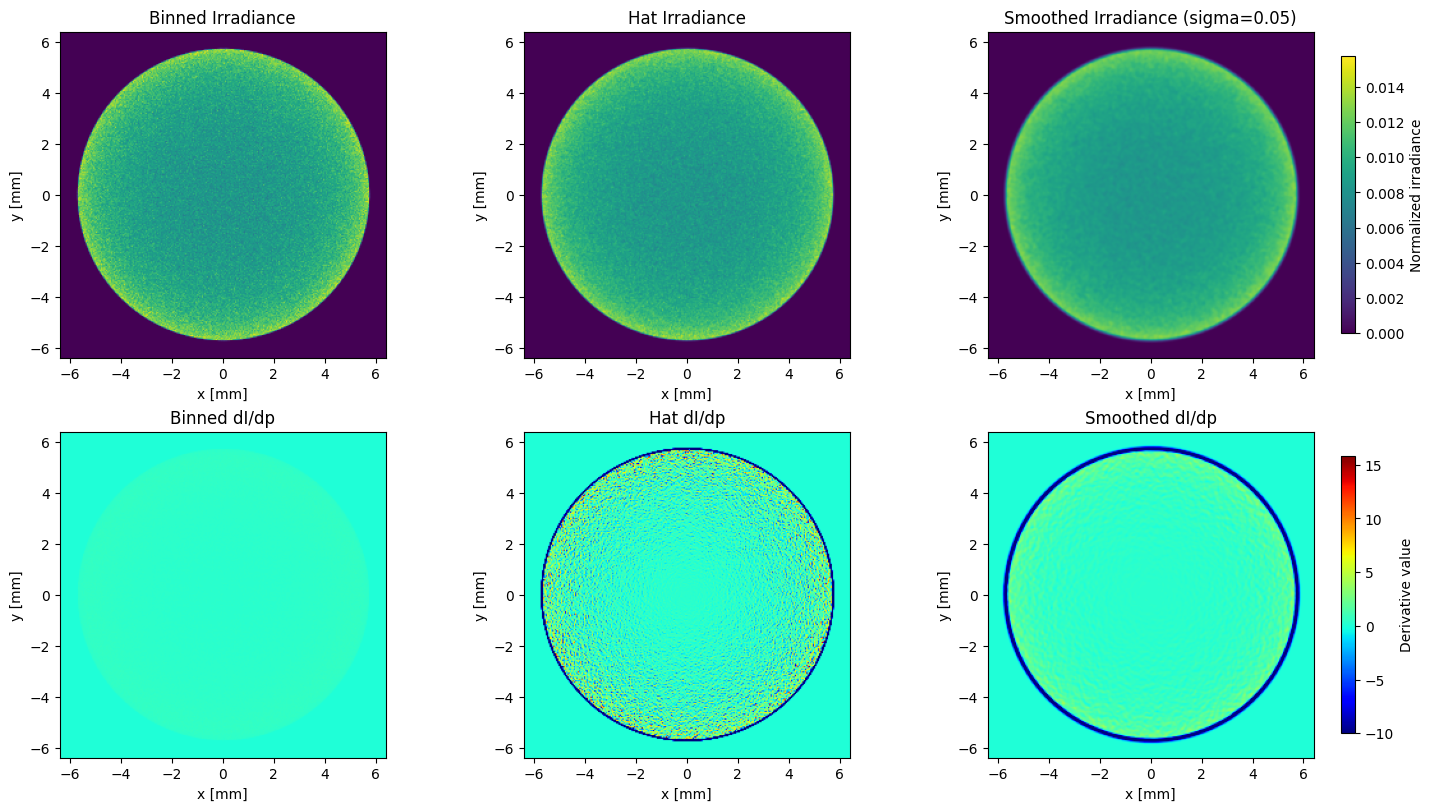

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Parameters
sigma = 0.05
num_rays_per_batch = 2**16
num_batches = 100

# Compute
irr_binned, d_binned = calc_binned_irr_and_derv(num_rays_per_batch, num_batches)
irr_hat, d_hat = calc_hat_fun_irr_and_derv(num_rays_per_batch, num_batches)
irr_smooth, d_smooth = calc_smooth_irr_and_derv(sigma, num_rays_per_batch, num_batches)


def _to_np(x):
    if hasattr(x, "detach"):
        x = x.detach()
    if hasattr(x, "cpu"):
        x = x.cpu()
    return np.asarray(x)


# Convert + normalize irradiance for fair visual comparison
I_b = _to_np(irr_binned)
I_h = _to_np(irr_hat)
I_s = _to_np(irr_smooth)

D_b = _to_np(d_binned)
D_h = _to_np(d_hat)
D_s = _to_np(d_smooth)



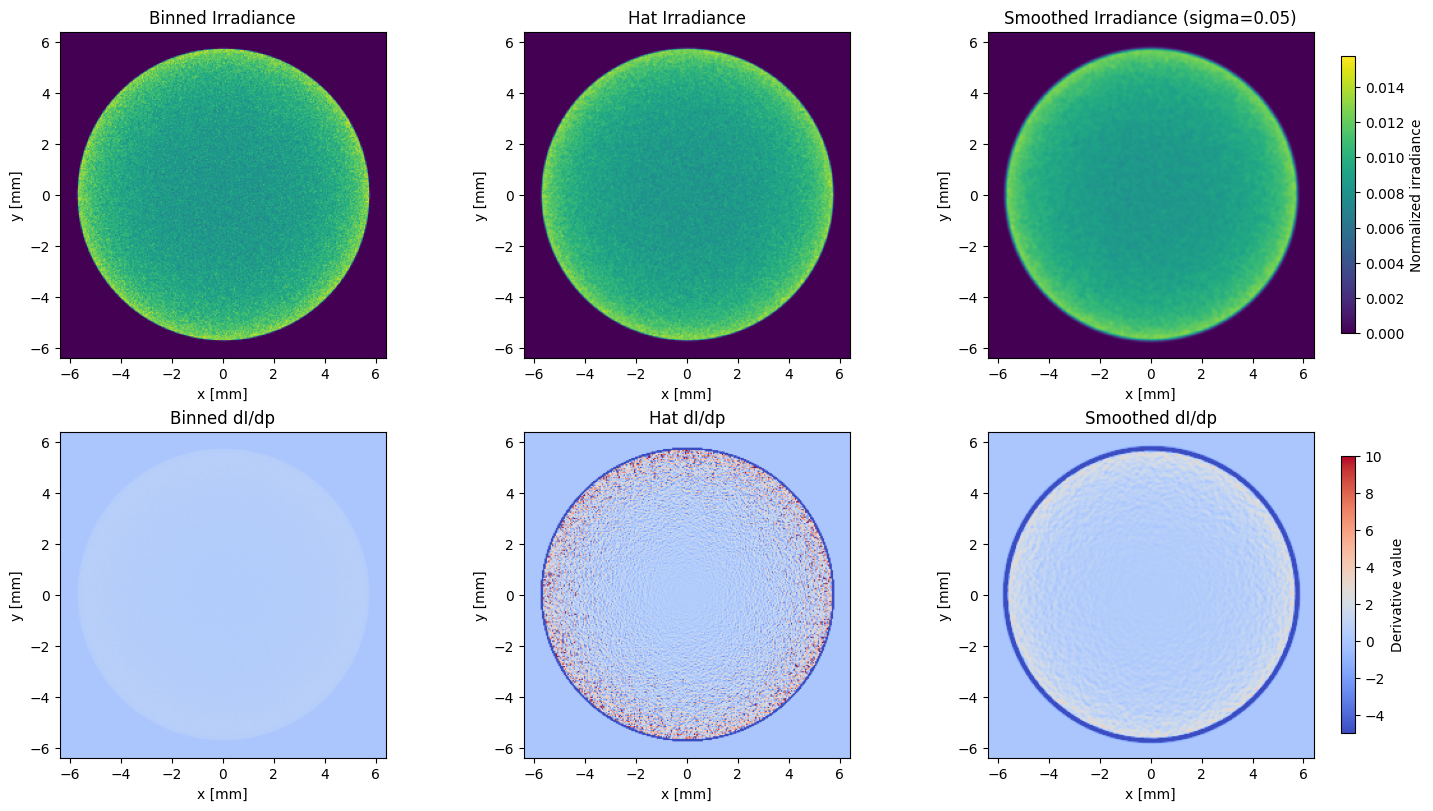

In [113]:
extent = [-final_plot_radius, final_plot_radius, -final_plot_radius, final_plot_radius]

# Shared scales
irr_vmin = min(I_b.min(), I_h.min(), I_s.min())
irr_vmax = max(I_b.max(), I_h.max(), I_s.max())


dirr_vmin = min(D_b.min(), D_h.min(), D_s.min())
dirr_vmax = max(D_b.max(), D_h.max(), D_s.max())
d_abs = max(np.abs(D_b).max(), np.abs(D_h).max(), np.abs(D_s).max())
d_norm = TwoSlopeNorm(vmin=dirr_vmin, vcenter=0.0, vmax=dirr_vmax)

# Plot: top row irradiance, bottom row derivative
fig, ax = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

im00 = ax[0, 0].imshow(I_b, extent=extent, origin="lower", cmap="viridis", vmin=irr_vmin, vmax=irr_vmax)
im01 = ax[0, 1].imshow(I_h, extent=extent, origin="lower", cmap="viridis", vmin=irr_vmin, vmax=irr_vmax)
im02 = ax[0, 2].imshow(I_s, extent=extent, origin="lower", cmap="viridis", vmin=irr_vmin, vmax=irr_vmax)

im10 = ax[1, 0].imshow(D_b, extent=extent, origin="lower",cmap="coolwarm",vmin=-5, vmax=10)
im11 = ax[1, 1].imshow(D_h, extent=extent, origin="lower",cmap="coolwarm",vmin=-5, vmax=10)
im12 = ax[1, 2].imshow(D_s, extent=extent, origin="lower",cmap="coolwarm",vmin=-5, vmax=10)

ax[0, 0].set_title("Binned Irradiance")
ax[0, 1].set_title("Hat Irradiance")
ax[0, 2].set_title(f"Smoothed Irradiance (sigma={sigma})")

ax[1, 0].set_title("Binned dI/dp")
ax[1, 1].set_title("Hat dI/dp")
ax[1, 2].set_title("Smoothed dI/dp")

for a in ax.ravel():
    a.set_xlabel("x [mm]")
    a.set_ylabel("y [mm]")

cbar_top = fig.colorbar(im02, ax=ax[0, :], shrink=0.85, pad=0.02)
cbar_top.set_label("Normalized irradiance")

cbar_bot = fig.colorbar(im12, ax=ax[1, :], shrink=0.85, pad=0.02)
cbar_bot.set_label("Derivative value")

plt.show()

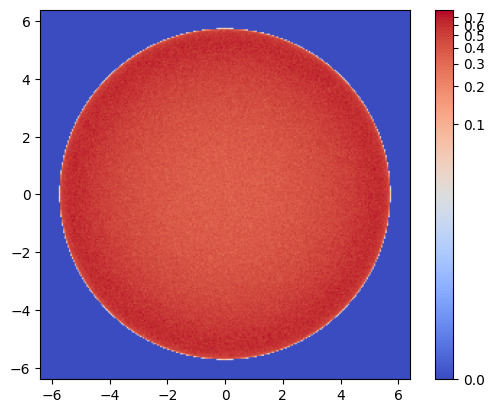

In [109]:
from matplotlib.colors import FuncNorm

absmax = max(np.abs(D_b).max(), np.abs(D_h).max(), np.abs(D_s).max())
linthresh = 1e-3

def forward(x):
    x = np.asarray(x)
    return np.sign(x) * np.log10(1 + np.abs(x) / linthresh)

def inverse(y):
    y = np.asarray(y)
    return np.sign(y) * linthresh * (10**np.abs(y) - 1)

norm = FuncNorm((forward, inverse), vmin=np.min(D_b), vmax=np.max(D_b))

plt.imshow(D_b, cmap="coolwarm", norm=norm, origin="lower", extent=extent)
plt.colorbar()

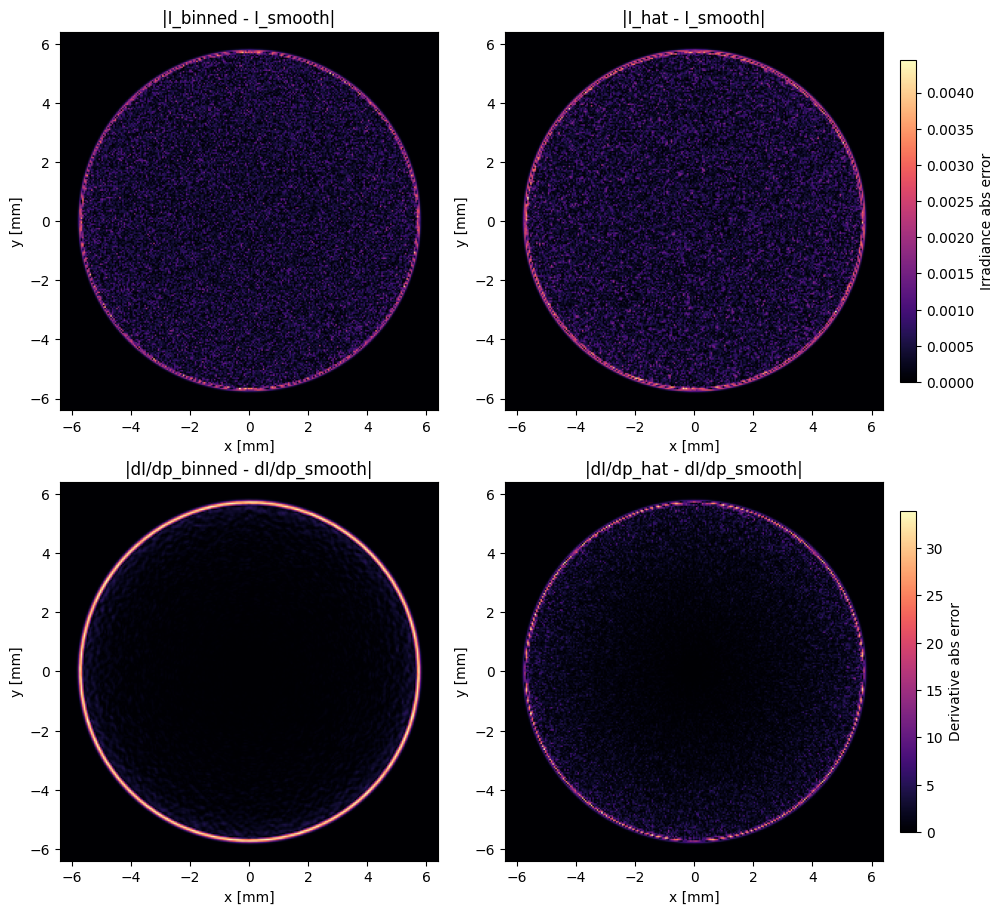

In [103]:
# Absolute error maps against smoothed reference
fig, ax = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)

err_I_b = np.abs(I_b - I_s)
err_I_h = np.abs(I_h - I_s)
err_D_b = np.abs(D_b - D_s)
err_D_h = np.abs(D_h - D_s)

im0 = ax[0, 0].imshow(err_I_b, extent=extent, origin="lower", cmap="magma")
im1 = ax[0, 1].imshow(err_I_h, extent=extent, origin="lower", cmap="magma")
im2 = ax[1, 0].imshow(err_D_b, extent=extent, origin="lower", cmap="magma")
im3 = ax[1, 1].imshow(err_D_h, extent=extent, origin="lower", cmap="magma")

ax[0, 0].set_title("|I_binned - I_smooth|")
ax[0, 1].set_title("|I_hat - I_smooth|")
ax[1, 0].set_title("|dI/dp_binned - dI/dp_smooth|")
ax[1, 1].set_title("|dI/dp_hat - dI/dp_smooth|")

for a in ax.ravel():
    a.set_xlabel("x [mm]")
    a.set_ylabel("y [mm]")

fig.colorbar(im1, ax=ax[0, :], shrink=0.85, pad=0.02, label="Irradiance abs error")
fig.colorbar(im3, ax=ax[1, :], shrink=0.85, pad=0.02, label="Derivative abs error")

plt.show()

In [ ]:

sigma = 0.05
num_rays_per_batch = 2**16
num_batches = 100
smooth_irr_derv = calc_smooth_irr_derv(sigma,num_rays_per_batch,num_batches)
binned_derv_slow = calc_binned_derv_v_slow(num_rays_per_batch,num_batches)


dit.plotting.quantity2D.plot(smooth_irr_derv, "Smoothed Irr Derv", [-final_plot_radius, final_plot_radius], [-final_plot_radius, final_plot_radius])
dit.plotting.quantity2D.plot(binned_derv_slow, "Binned Derv", [-final_plot_radius, final_plot_radius], [-final_plot_radius, final_plot_radius])
dit.plotting.quantity2D.plot(torch.abs(binned_derv_slow-smooth_irr_derv), "Distance", [-final_plot_radius, final_plot_radius], [-final_plot_radius, final_plot_radius],vmin=smooth_irr_derv.min(),vmax=smooth_irr_derv.max())


"""


final_plot_radius = lens.film_size[0]*lens.pixel_size/2

dit.plotting.quantity2D.plot(Iss[0]/(Iss[0]*lens.pixel_size**2).sum(),"Irradiance",[-final_plot_radius,final_plot_radius])
#%%
#dit.plotting.quantity2D.plot(Jss[0]/(Iss[0]*lens.pixel_size**2).sum(),"Derivative",[-final_plot_radius,final_plot_radius])

val = Jss[0]/(Iss[0]*lens.pixel_size**2).sum()
x_range = [-final_plot_radius,final_plot_radius]
y_range = [-final_plot_radius,final_plot_radius]
from matplotlib.colors import LogNorm
norm = LogNorm()
plt.imshow(val,cmap="jet",extent=list(x_range)+list(y_range),norm=norm)
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.colorbar()    
#%%

val = Iss[0]/(Iss[0]*lens.pixel_size**2).sum()
x_range = [-final_plot_radius,final_plot_radius]
y_range = [-final_plot_radius,final_plot_radius]
from matplotlib.colors import LogNorm
norm = LogNorm()
plt.imshow(val,cmap="jet",extent=list(x_range)+list(y_range))
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.colorbar()    
#%%


"""
#%%
"""
#binned_derv_slow = calc_binned_derv_v_slow(num_rays_per_batch,num_batches)
sigmas = torch.linspace(1.,0.03,5)
smooth_irr_dervs = []
distances_smooth_binned = []    
for sigma in sigmas:
    smooth_irr_derv = calc_smooth_irr_derv(sigma,num_rays_per_batch,num_batches).detach().cpu()
    smooth_irr_dervs.append(smooth_irr_derv)
    print(torch.linalg.norm(binned_derv_slow-smooth_irr_derv))
    distances_smooth_binned.append(torch.linalg.norm(binned_derv_slow.detach().cpu()-smooth_irr_derv))"""
#%%

"""def u_mapping(x):
    O,D,wave_len,_,RayPaths = system(x,sequence)
    O_local = detector.to_local_pos(O)
    return O_local[:,[0,1]],O
    

     
#square_collimated = dit.source.CollimatedMonochromatic(light_transform,aperture_radius,wave_len,is_square=False)
#x,weights = square_collimated.sample([100,100],"midpoint")
x,weights = light_source.sample(10000)
Qval = light_source.get_flux(x.detach()).detach()
x = x.to(device)
Qval = Qval.to(device)
x.requires_grad = True
#x = x[torch.linalg.norm(x,dim=-1)<aperture_radius]
weights = weights.to(device)
y,O = u_mapping(x)
dy1_dx, = dit.grad(y[:,0],inputs=[x],grad_outputs=torch.ones_like(y[:,0]))
dy2_dx, = dit.grad(y[:,1],inputs=[x],grad_outputs=torch.ones_like(y[:,1]))
dy_dx = torch.zeros((x.shape[0],2,2),device=device)
dy_dx[:,0] = dy1_dx
dy_dx[:,1] = dy2_dx
H = torch.abs(torch.det(dy_dx)).reshape(-1)
irr = Qval*(1.0/H)
tmp = torch.ones_like(irr)
tmp.requires_grad = True

dp_summed, = dit.grad(irr,inputs=[surface1.curvature],grad_outputs=tmp,materialize_grads=True)
            
irr_p, = dit.grad(dp_summed,inputs=[tmp])

irr_p = irr_p.detach().cpu()

ynp = y.cpu().detach().numpy()

dit.plotting.quantity2D.plot(binned_derv_slow, "Binned Derv", [-final_plot_radius, final_plot_radius], [-final_plot_radius, final_plot_radius],vmax=irr_p.max())
irradiance_binned = calc_rc_irr(2**19,100)
dit.plotting.quantity2D.plot(irradiance_binned, "Smoothed Irradiance", [-final_plot_radius, final_plot_radius], [-final_plot_radius, final_plot_radius])
num_rays = 2**19
def gp2(x):
    O,D,wave_len,_,RayPaths = system(x,sequence)
    O_local = detector.to_local_pos(O)
    return O_local[:,[0,1]],O
x,weights = light_source.sample(num_rays)
num_rays = x.shape[0]
grid = dit.target_grid.GridSquare(aperture_radius,grid_size=grid_size)

"""
